In [62]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
dataset = load_breast_cancer()

dataset

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [63]:
X = dataset.data
Y = dataset.target

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.4)

In [64]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(criterion="gini")

model.fit(X_train, Y_train)

DecisionTreeClassifier()

In [65]:
ypred = model.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
accuracy_score(Y_test, ypred)
print(accuracy_score(Y_test, ypred), precision_score(Y_test, ypred), recall_score(Y_test, ypred))

0.8947368421052632 0.9463087248322147 0.8980891719745223


[Text(0.6323529411764706, 0.9166666666666666, 'x[20] <= 16.795\ngini = 0.485\nsamples = 341\nvalue = [141, 200]'),
 Text(0.4411764705882353, 0.75, 'x[27] <= 0.136\ngini = 0.148\nsamples = 211\nvalue = [17, 194]'),
 Text(0.5367647058823529, 0.8333333333333333, 'True  '),
 Text(0.23529411764705882, 0.5833333333333334, 'x[10] <= 0.603\ngini = 0.021\nsamples = 188\nvalue = [2, 186]'),
 Text(0.11764705882352941, 0.4166666666666667, 'x[21] <= 32.83\ngini = 0.011\nsamples = 186\nvalue = [1, 185]'),
 Text(0.058823529411764705, 0.25, 'gini = 0.0\nsamples = 172\nvalue = [0, 172]'),
 Text(0.17647058823529413, 0.25, 'x[27] <= 0.09\ngini = 0.133\nsamples = 14\nvalue = [1, 13]'),
 Text(0.11764705882352941, 0.08333333333333333, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.23529411764705882, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.35294117647058826, 0.4166666666666667, 'x[7] <= 0.032\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.29411764705882354, 0.25, 

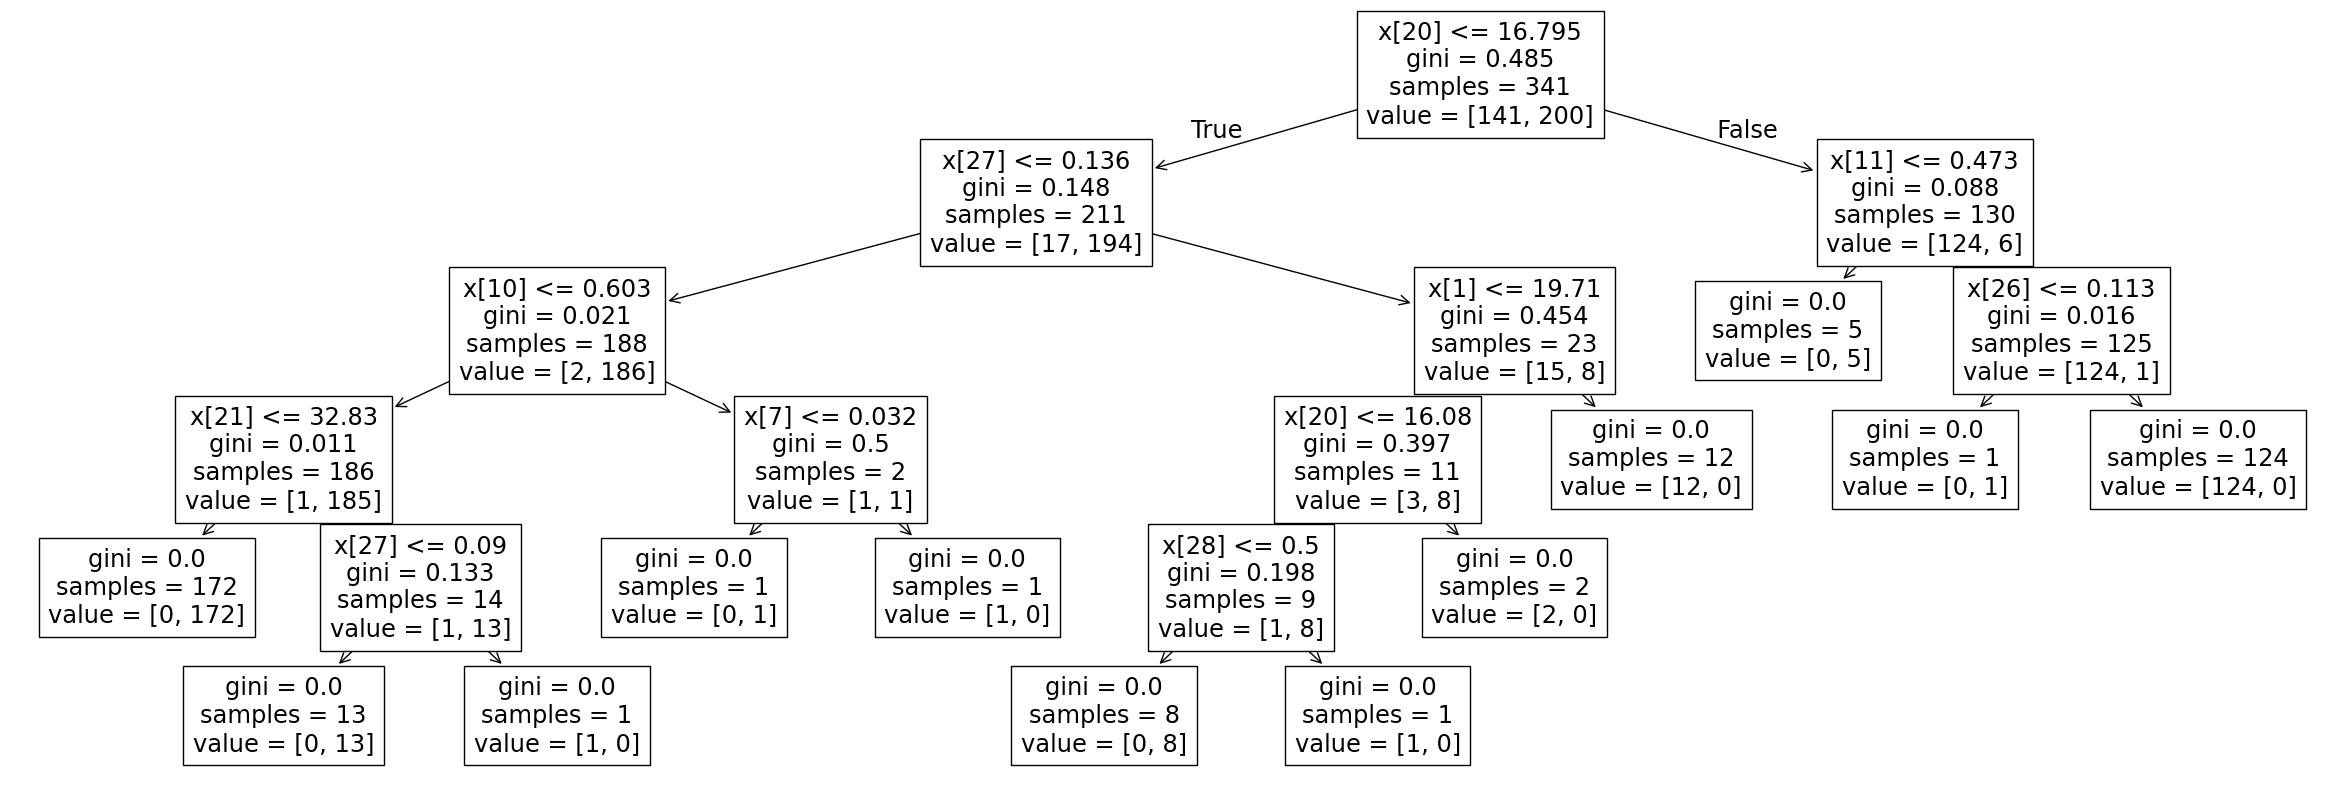

In [67]:
import matplotlib.pyplot as plt

plt.figure(
  figsize=(30,10)
)

plot_tree(model)

In [68]:
path = model.cost_complexity_pruning_path(X_train, Y_train)

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

alphas = path.ccp_alphas
scores = []

for a in alphas:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    score = cross_val_score(clf, X, Y, cv=5).mean()
    scores.append(score)

best_alpha = alphas[np.argmax(scores)]
print(best_alpha)


0.01780394793272519


In [72]:
model2 = DecisionTreeClassifier(ccp_alpha=.01780394793272519)
model2.fit(X_train, Y_train)
y_pred2 = model2.predict(X_test)
accuracy_score(Y_test, y_pred2)

0.9166666666666666

[Text(0.5, 0.8333333333333334, 'x[20] <= 16.795\ngini = 0.485\nsamples = 341\nvalue = [141, 200]'),
 Text(0.25, 0.5, 'x[27] <= 0.136\ngini = 0.148\nsamples = 211\nvalue = [17, 194]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.021\nsamples = 188\nvalue = [2, 186]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.454\nsamples = 23\nvalue = [15, 8]'),
 Text(0.75, 0.5, 'x[11] <= 0.473\ngini = 0.088\nsamples = 130\nvalue = [124, 6]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.016\nsamples = 125\nvalue = [124, 1]')]

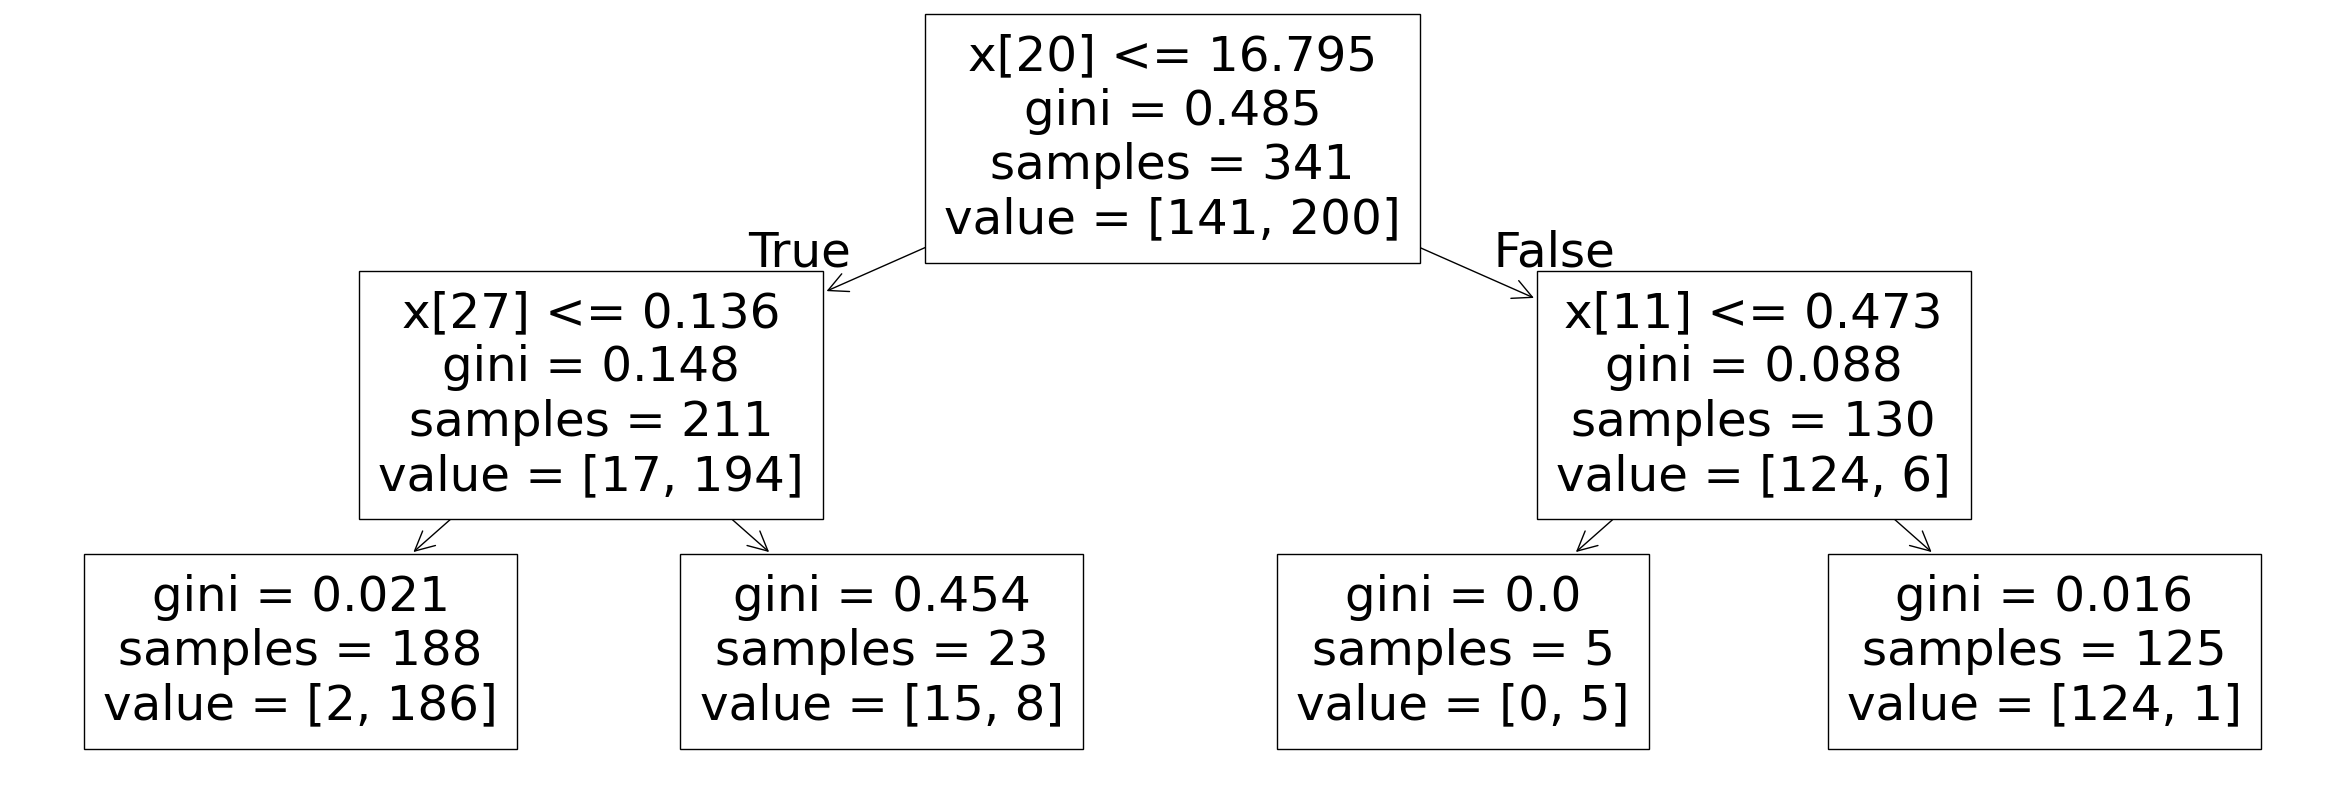

In [73]:
import matplotlib.pyplot as plt

plt.figure(
  figsize=(30,10)
)

plot_tree(model2)

[Text(0.5, 0.8333333333333334, 'x[20] <= 16.795\ngini = 0.485\nsamples = 341\nvalue = [141, 200]'),
 Text(0.25, 0.5, 'x[27] <= 0.136\ngini = 0.148\nsamples = 211\nvalue = [17, 194]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.021\nsamples = 188\nvalue = [2, 186]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.454\nsamples = 23\nvalue = [15, 8]'),
 Text(0.75, 0.5, 'x[11] <= 0.473\ngini = 0.088\nsamples = 130\nvalue = [124, 6]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.016\nsamples = 125\nvalue = [124, 1]')]

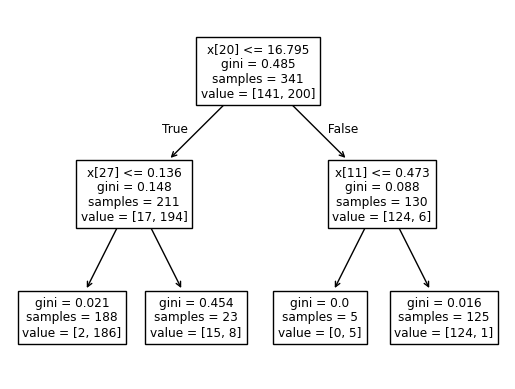

In [76]:
from sklearn.tree import export_graphviz, plot_tree
# export_graphviz(model)
# export_graphviz(model2)

plot_tree(model2)